# PSF Visualization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import circulant

In [2]:
def build_horizontal_motion_psf(length, img_shape):
    """Build horizontal motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    psf[0, :length] = 1 / length
    return psf

def build_vertical_motion_psf(length, img_shape):
    """Build vertical motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    psf[:length, 0] = 1 / length
    return psf

def get_pixel_pos_for_angled_linear_motion_vis(length, angle_deg):
    """Return a list of pixel coordinates for a motion blur line of given length and angle."""
    
    len_list = np.linspace(1, length, num=(length * 2))
    pos_set = set()
    shifted_rad = np.radians(angle_deg)

    for l in len_list:
        x_pos = round( np.cos(shifted_rad) * l )
        y_pos = round( -np.sin(shifted_rad) * l )
        pos_set.add((y_pos, x_pos))
        
    return list(pos_set)

def build_linear_motion_psf_vis(length, angle_deg, img_shape):
    """Build angled linear motion psf with padding zeros.
    The position is shifted to the center for visualization."""
    
    psf = np.zeros(img_shape)
    positions = get_pixel_pos_for_angled_linear_motion_vis(length, angle_deg)
    center_x, center_y = img_shape[0] // 2, img_shape[1] // 2

    for y, x in positions:
        psf[y + center_y, x + center_x] = 1 / len(positions)
        
    return psf

def build_guassian_psf_vis(img_shape, sigma=3.0):
    H, W = img_shape
    y = np.arange(-H // 2, H // 2)
    x = np.arange(-W // 2, W // 2)
    X, Y = np.meshgrid(x, y)
    psf = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    psf /= psf.sum()
    
    return psf

In [3]:
def plot_psf(arr, title, color):
    _, plot = plt.subplots()
    plot.imshow(arr, cmap='gray')
    plot.set_xticks(np.arange(-.5, arr.shape[1], 1), minor=True)
    plot.set_yticks(np.arange(-.5, arr.shape[0], 1), minor=True)
    plot.grid(which='minor', color=color, linewidth=0.5)
    plot.tick_params(which='minor', length=0)
    plot.set_xticks([])
    plot.set_yticks([])
    plot.set_title(title)

In [19]:
def plot_grid(arr, title, cell_size=0.4):
    figsize = (arr.shape[1] * cell_size, arr.shape[0] * cell_size)
    _, plot = plt.subplots(figsize=figsize)
    plot.imshow(arr, cmap='gray', vmin=0, vmax=0.1)
    
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color = 'black' if arr[i, j] > 0 else 'white'
            plot.text(j, i, arr[i, j], ha='center', va='center', color=color)
    
    plot.set_xticks(np.arange(-.5, arr.shape[1], 1), minor=True)
    plot.set_yticks(np.arange(-.5, arr.shape[0], 1), minor=True)
    plot.grid(which='minor', color='gray', linewidth=0.5)
    plot.tick_params(which='minor', length=0)
    plot.set_xticks([])
    plot.set_yticks([])
    plot.set_title(title)

In [5]:
def build_bccb(psf):
    """Build BCCB matrix A from a 2D PSF (Do not put a big psf)."""
    len_row, len_col = psf.shape
    blocks = [circulant(psf[m]) for m in range(len_row)]
    # Arrange blocks in a block-circulant pattern
    A = np.zeros((len_row * len_col, len_row * len_col))
    for m in range(len_row):
        for n in range(len_row):
            A[m * len_col : (m + 1) * len_col, n * len_col : (n + 1) * len_col] = blocks[(m - n) % len_row]
    return A

----------
# PSF Visualization

In [15]:
length = 10
shape = (10,10)

### Horizontal PSF

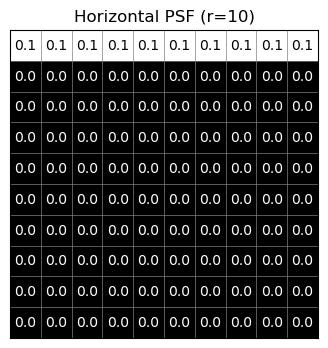

In [20]:
ex1_h_psf = build_horizontal_motion_psf(length, shape)
plot_grid(ex1_h_psf, f'Horizontal PSF (r={length})')

### Vertical PSF

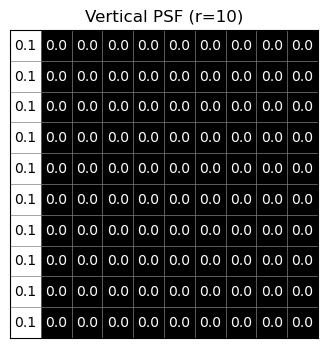

In [ ]:
ex1_v_psf = build_vertical_motion_psf(length, shape)
plot_grid(ex1_v_psf, f'Vertical PSF (r={length})')

### Linear 20° PSF

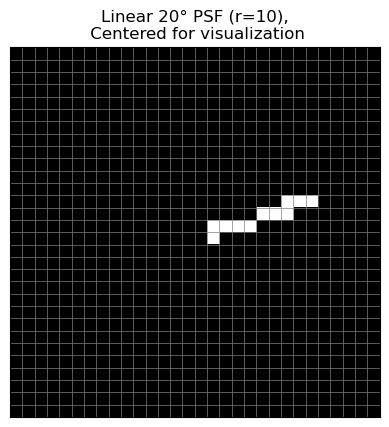

In [26]:
centered_shape = (30, 30)
ex2_20deg_psf = build_linear_motion_psf_vis(length, 20, centered_shape)
plot_psf(ex2_20deg_psf, f'Linear 20° PSF (r={length}),\n Centered for visualization', 'gray')

### Linear 135° PSF

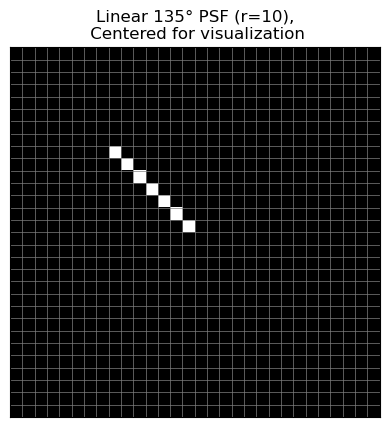

In [27]:
ex2_135deg_psf = build_linear_motion_psf_vis(length, 135, centered_shape)
plot_psf(ex2_135deg_psf, f'Linear 135° PSF (r={length}),\n Centered for visualization', 'gray')

### Linear 250° PSF

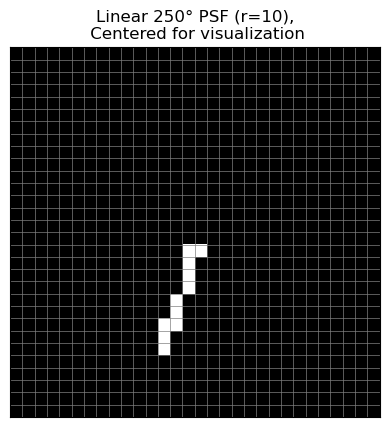

In [28]:
ex2_250deg_psf = build_linear_motion_psf_vis(length, 250, centered_shape)
plot_psf(ex2_250deg_psf, f'Linear 250° PSF (r={length}),\n Centered for visualization', 'gray')

### Gaussian PSF

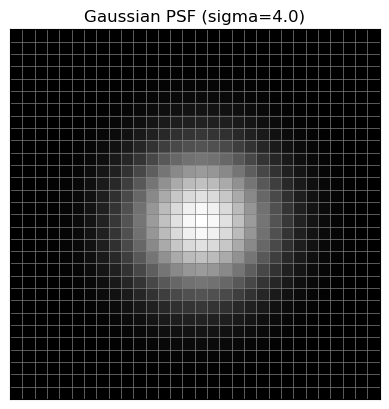

In [12]:
sigma_small = 4.0
ex_gaussian_psf = build_guassian_psf_vis((30,30), sigma=sigma_small)
plot_psf(ex_gaussian_psf, f'Gaussian PSF (sigma={sigma_small})', 'gray')

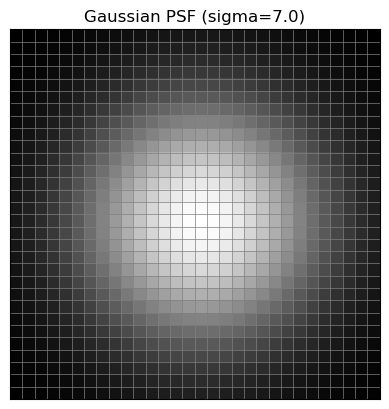

In [13]:
sigma_big = 7.0
ex_gaussian_psf = build_guassian_psf_vis((30,30), sigma=sigma_big)
plot_psf(ex_gaussian_psf, f'Gaussian PSF (sigma={sigma_big})', 'gray')